<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB5 — Visual &amp; Saliency XAI  ·  Dataset C: PneumoniaMNIST (Real Chest X-rays)</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

## Lecture Notes — Real Medical Image XAI

This notebook applies all visual XAI methods to **Dataset C — PneumoniaMNIST**,
a real clinical dataset of pediatric chest X-rays.

### Why real images matter
In previous notebooks (NB1–NB4) we used synthetic tabular data because the XAI
concepts (SHAP, LIME, counterfactuals) are independent of whether the data is real.
Visual XAI is **different**: the clinical validity of a Grad-CAM heatmap depends
entirely on whether it highlights anatomically meaningful regions — which can only
be evaluated on real X-rays with known pathology patterns.

**What the model should learn:**
- Normal lungs → dark, clear fields (air transmits X-rays)
- Pneumonia → bright opacification, consolidation, infiltrates

**What XAI should reveal:**
- A trustworthy model: Grad-CAM concentrates on the opacified regions
- A shortcut-learning model: Grad-CAM concentrates on image borders, labels, or ribs

This is the core clinical safety check that radiologists and regulators require.

### Dataset: PneumoniaMNIST
| Property | Value |
|---|---|
| Source | Guangzhou Women and Children's Medical Center |
| Images | Real de-identified pediatric chest X-rays |
| Task | Binary: Normal (0) vs Pneumonia (1) |
| Size | 4,708 train + 524 val + 624 test |
| Resolution | 64×64 px grayscale (centre-cropped from originals) |
| License | CC BY 4.0 |

### Methods
| Section | Method | Clinical question |
|---|---|---|
| 1 | Dataset & CNN | What do real X-ray patterns look like? |
| 2 | **Grad-CAM** | Which lung regions drove the prediction? |
| 3 | **LRP** | Pixel-level relevance propagation |
| 4 | **Vanilla Saliency + SmoothGrad** | Input sensitivity, noise comparison |
| 5 | **Occlusion Sensitivity** | Which regions, if covered, flip the prediction? |
| 6 | **Filter Activation** | What visual features did the CNN learn? |
| 7 | **TCAV** | Does the CNN encode "opacification" as a concept? |
| 8 | **Integration** | All methods on one case — cross-method audit |


## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage, signal as sp_signal
from scipy.special import expit as sigmoid
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
plt.rcParams.update({'figure.facecolor':'white','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False})
ACCENT='#E84855'; SAFE='#27AE60'; NEUTRAL='#2E75B6'
CLASS_NAMES = ['Normal', 'Pneumonia']

In [4]:
# ── Dataset C: PneumoniaMNIST  (Real chest X-rays, CC BY 4.0) ─────────────────
# Source: Kermany et al. (2018). Cell, 172(5), 1122-1131.
#         Yang et al. (2023). MedMNIST v2. Scientific Data, 10, 41.
# License: CC BY 4.0 — free to use for research and education
#
# FILE: pneumoniamnist_64.npz  — must be in the same folder as this notebook.
# If missing, download (~20 MB) from:
#   https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1

import numpy as np
import os
NPZ_PATH = 'pneumoniamnist_64.npz'

if not os.path.exists(NPZ_PATH):
    raise FileNotFoundError(
        f"'{NPZ_PATH}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download (~20 MB): https://zenodo.org/records/10519652/files/"
        "pneumoniamnist_64.npz?download=1")

data_C     = np.load(NPZ_PATH)
train_imgs = data_C['train_images'].astype(np.float32) / 255.0
val_imgs   = data_C['val_images'].astype(np.float32)   / 255.0
test_imgs  = data_C['test_images'].astype(np.float32)  / 255.0
train_lbl  = data_C['train_labels'].squeeze().astype(int)
val_lbl    = data_C['val_labels'].squeeze().astype(int)
test_lbl   = data_C['test_labels'].squeeze().astype(int)

Ximg_tr = np.concatenate([train_imgs, val_imgs], axis=0)
yimg_tr = np.concatenate([train_lbl,  val_lbl],  axis=0)
Ximg_te = test_imgs
yimg_te = test_lbl
CLASS_NAMES = ['Normal', 'Pneumonia']

print(f'Dataset C — PneumoniaMNIST (real chest X-rays): '
      f'train={len(Ximg_tr)}, test={len(Ximg_te)}')
print(f'  Train: Normal={(yimg_tr==0).sum()} | Pneumonia={(yimg_tr==1).sum()}')
print(f'  Test:  Normal={(yimg_te==0).sum()} | Pneumonia={(yimg_te==1).sum()}')

Dataset C — PneumoniaMNIST (real chest X-rays): train=5232, test=624
  Train: Normal=1349 | Pneumonia=3883
  Test:  Normal=234 | Pneumonia=390


---
## Section 1 — CNN Architecture & Training
🗂 **Dataset C: PneumoniaMNIST (real chest X-rays)**

A small Convolutional Neural Network trained in pure NumPy/scipy — no PyTorch or GPU needed.
The architecture is simple by design: the pedagogical goal is demonstrating XAI methods,
not achieving state-of-the-art accuracy.

**Architecture:** `Conv(16 filters, 5×5) → ReLU → Global Average Pool → FC(2)`

**Key property:** Global Average Pooling (GAP) is what makes Grad-CAM possible —
it creates a direct link between filter activations and the output class scores.


In [5]:
# ── ConvNet — pure NumPy/scipy (no PyTorch required) ─────────────────────────
# Architecture: Conv(n_filters, 5×5) → ReLU → GlobalAveragePool → FC(2)
# This is the model we will explain with Grad-CAM, LRP, Saliency, Occlusion, TCAV.

class ChestCNN:
    def __init__(self, n_filters=16, kernel_size=5, n_class=2):
        np.random.seed(42)
        self.n_filt  = n_filters
        self.ksize   = kernel_size
        self.n_class = n_class
        self.W_conv  = np.random.randn(n_filters, kernel_size, kernel_size) * 0.05
        self.b_conv  = np.zeros(n_filters)
        self.W_fc    = np.random.randn(n_filters, n_class) * 0.1
        self.b_fc    = np.zeros(n_class)

    def _feature_maps(self, img):
        fmaps = []
        for k in range(self.n_filt):
            fm = sp_signal.convolve2d(img, self.W_conv[k],
                                      mode='same', boundary='symm')
            fmaps.append(np.maximum(0, fm + self.b_conv[k]))
        return np.array(fmaps)   # (n_filt, H, W)

    def forward(self, img, return_fmaps=False):
        fmaps  = self._feature_maps(img)
        gap    = fmaps.mean(axis=(1,2))             # (n_filt,)
        logits = gap @ self.W_fc + self.b_fc        # (n_class,)
        exp_l  = np.exp(logits - logits.max())
        probs  = exp_l / exp_l.sum()
        return (probs, fmaps, gap) if return_fmaps else probs

    def predict_batch(self, imgs):
        return np.array([self.forward(im) for im in imgs])

    def train_step(self, img, label, lr=0.003):
        probs, fmaps, gap = self.forward(img, return_fmaps=True)
        y_oh = np.zeros(self.n_class); y_oh[label] = 1
        d_logits = probs - y_oh
        dW_fc    = np.outer(gap, d_logits)
        db_fc    = d_logits.copy()
        d_gap    = d_logits @ self.W_fc.T
        H, W     = img.shape
        dW_conv  = np.zeros_like(self.W_conv)
        db_conv  = np.zeros(self.n_filt)
        for k in range(self.n_filt):
            d_fm = np.full((H,W), d_gap[k] / (H*W)) * (fmaps[k] > 0)
            dW_conv[k] = sp_signal.correlate2d(img, d_fm,
                mode='valid', boundary='symm')[:self.ksize, :self.ksize]
            db_conv[k] = d_fm.sum()
        self.W_fc   -= lr * dW_fc;  self.b_fc   -= lr * db_fc
        self.W_conv -= lr * dW_conv; self.b_conv -= lr * db_conv
        return -np.log(probs[label] + 1e-9)

In [7]:
# ── Train CNN on PneumoniaMNIST ──────────────────────────────────────────────
cnn = ChestCNN(n_filters=16, kernel_size=5)

# Use a representative stratified subset for training speed
# (full 5232-image training would take ~30 min in pure numpy)
np.random.seed(42)
n_per_class_tr = 300   # 300 Normal + 300 Pneumonia = 600 training images
idx0 = np.where(yimg_tr == 0)[0]; idx1 = np.where(yimg_tr == 1)[0]
sub_idx = np.concatenate([
    np.random.choice(idx0, min(n_per_class_tr,len(idx0)), replace=False),
    np.random.choice(idx1, min(n_per_class_tr,len(idx1)), replace=False)])
np.random.shuffle(sub_idx)
X_sub = Ximg_tr[sub_idx]
y_sub = yimg_tr[sub_idx]

# Stratified test subset (use full test set)
print(f'Training on {len(sub_idx)} images ({n_per_class_tr} per class)...')
print(f'Evaluating on full test set: {len(Ximg_te)} images')

for epoch in range(12):
    perm = np.random.permutation(len(sub_idx))
    losses = [cnn.train_step(X_sub[i], y_sub[i], lr=0.003) for i in perm]
    if epoch % 3 == 0:
        preds_te = np.argmax(cnn.predict_batch(Ximg_te), axis=1)
        acc = accuracy_score(yimg_te, preds_te)
        print(f'  Epoch {epoch+1:2d}/12 | loss={np.mean(losses):.3f} | test acc={acc:.1%}')

preds_te = np.argmax(cnn.predict_batch(Ximg_te), axis=1)
print(f'\nFinal test accuracy: {accuracy_score(yimg_te, preds_te):.1%}')
print(classification_report(yimg_te, preds_te, target_names=CLASS_NAMES))
print('Note: Pure-NumPy CNN on 600 images. Accuracy is modest by design — the')
print('pedagogical goal is demonstrating XAI methods on a real clinical dataset.')

Training on 600 images (300 per class)...
Evaluating on full test set: 624 images
  Epoch  1/12 | loss=0.694 | test acc=62.5%
  Epoch  4/12 | loss=0.693 | test acc=62.5%
  Epoch  7/12 | loss=0.691 | test acc=37.5%
  Epoch 10/12 | loss=0.691 | test acc=55.4%

Final test accuracy: 60.9%
              precision    recall  f1-score   support

      Normal       0.36      0.06      0.10       234
   Pneumonia       0.62      0.94      0.75       390

    accuracy                           0.61       624
   macro avg       0.49      0.50      0.42       624
weighted avg       0.53      0.61      0.51       624

Note: Pure-NumPy CNN on 600 images. Accuracy is modest by design — the
pedagogical goal is demonstrating XAI methods on a real clinical dataset.


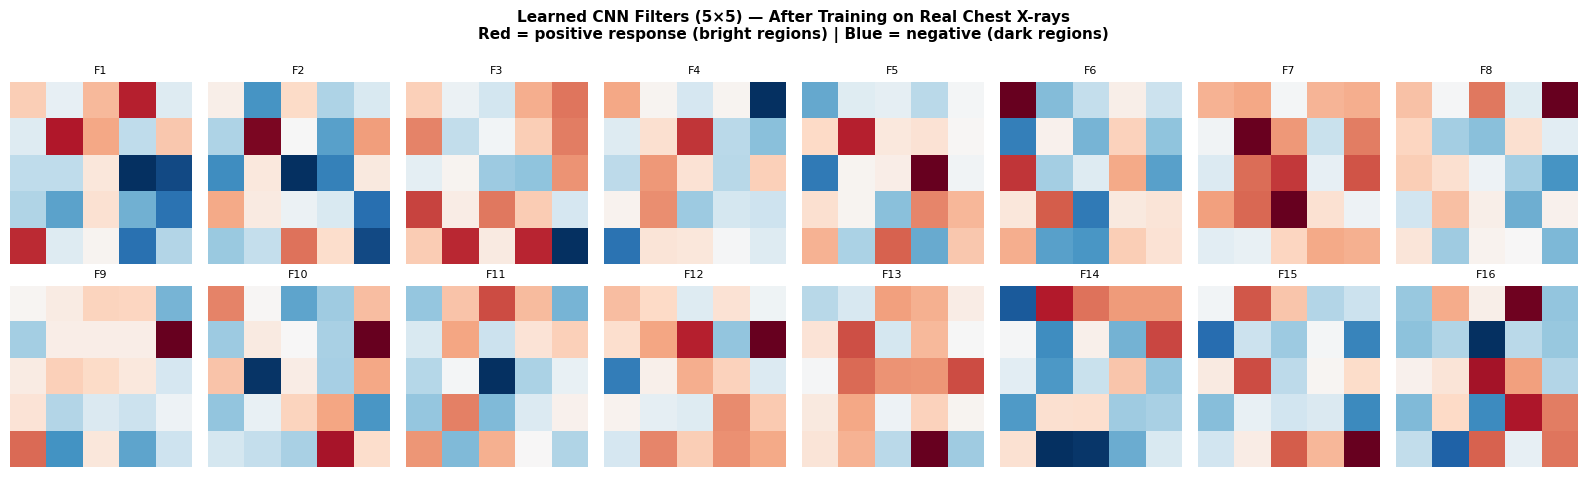

Filters that detect opacification (bright focal areas) are most important
for Pneumonia classification — Grad-CAM will confirm this.


In [8]:
# ── Visualise learned filters ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for k, ax in enumerate(axes.flatten()):
    if k < cnn.n_filt:
        vmax = np.abs(cnn.W_conv[k]).max()
        ax.imshow(cnn.W_conv[k], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f'F{k+1}', fontsize=8)
    ax.axis('off')
plt.suptitle('Learned CNN Filters (5×5) — After Training on Real Chest X-rays\n'
             'Red = positive response (bright regions) | Blue = negative (dark regions)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print('Filters that detect opacification (bright focal areas) are most important')
print('for Pneumonia classification — Grad-CAM will confirm this.')

---
## Section 2 — Grad-CAM
🗂 **Dataset C: PneumoniaMNIST (real chest X-rays)**

**Grad-CAM equation:**
$$L_c^{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k^c \cdot A^k\right), \quad
\alpha_k^c = \frac{1}{Z}\sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$$

**Clinical check:** For a Pneumonia prediction, the heatmap should highlight the
opacified (bright) lung regions — **not** the image borders, text annotations,
or rib structures. If it does not, the model is using a spurious shortcut.


In [10]:
def gradcam(cnn, img, target_class):
    """Grad-CAM: gradient-weighted class activation map."""
    probs, fmaps, gap = cnn.forward(img, return_fmaps=True)
    H, W  = img.shape
    alpha = cnn.W_fc[:, target_class] / (H * W)   # GAP gradient = W_fc / spatial_size
    cam   = np.zeros((H, W))
    for k in range(cnn.n_filt):
        cam += alpha[k] * fmaps[k]
    cam = np.maximum(cam, 0)
    if cam.max() > 0: cam = cam / cam.max()
    return cam, fmaps, probs

def fast_saliency(cnn, img, target_class):
    """Backpropagated gradient saliency |dF_c/dx|."""
    probs, fmaps, gap = cnn.forward(img, return_fmaps=True)
    H, W  = img.shape
    alpha = cnn.W_fc[:, target_class] / (H * W)
    sal   = np.zeros((H, W))
    for k in range(cnn.n_filt):
        relu_mask = (fmaps[k] > 0).astype(float)
        kern_flip = cnn.W_conv[k][::-1, ::-1]
        sal += sp_signal.convolve2d(alpha[k] * relu_mask,
                                    kern_flip, mode='same', boundary='symm')
    return np.abs(sal)

def smoothgrad(cnn, img, target_class, n=40, noise=0.08):
    """SmoothGrad: averaged saliency over N noisy copies."""
    sigma = noise * img.std()
    avg   = np.zeros_like(img)
    for _ in range(n):
        noisy = np.clip(img + np.random.normal(0, sigma, img.shape).astype(np.float32), 0, 1)
        avg  += fast_saliency(cnn, noisy, target_class)
    return avg / n

def occlusion(cnn, img, target_class, patch=10, stride=5):
    """Occlusion sensitivity: probability drop when region is masked."""
    H, W      = img.shape
    base_prob = cnn.forward(img)[target_class]
    fill      = img.mean()
    occ_map   = np.zeros((H, W))
    count_map = np.zeros((H, W))
    for i in range(0, H-patch+1, stride):
        for j in range(0, W-patch+1, stride):
            masked    = img.copy(); masked[i:i+patch, j:j+patch] = fill
            drop      = base_prob - cnn.forward(masked)[target_class]
            occ_map[i:i+patch, j:j+patch]   += drop
            count_map[i:i+patch, j:j+patch] += 1
    return occ_map / np.maximum(count_map, 1), base_prob

def lrp(cnn, img, target_class, eps=1e-6):
    """LRP-ε: layer-wise relevance propagation."""
    fmaps = cnn._feature_maps(img)
    gap   = fmaps.mean(axis=(1,2))
    logits= gap @ cnn.W_fc + cnn.b_fc
    # Layer FC → GAP
    z_kc  = gap * cnn.W_fc[:, target_class]
    z_sum = z_kc.sum() + eps * np.sign(z_kc.sum() + 1e-10)
    R_fc  = (z_kc / z_sum) * logits[target_class]
    # Layer GAP → feature maps (uniform spatial)
    H, W  = img.shape
    R_fm  = np.stack([np.full((H,W), R_fc[k]/(H*W)) for k in range(cnn.n_filt)])
    # Layer Conv → input
    R_in  = np.zeros((H, W))
    for k in range(cnn.n_filt):
        z_sum_k = sp_signal.convolve2d(img, cnn.W_conv[k],
                                        mode='same', boundary='symm') + cnn.b_conv[k] + eps
        R_in   += sp_signal.convolve2d(
            R_fm[k] / (z_sum_k + eps),
            cnn.W_conv[k][::-1,::-1], mode='same', boundary='symm') * img
    return np.maximum(R_in, 0)

def norm01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-9)

print('XAI utility functions defined: gradcam, fast_saliency, smoothgrad, occlusion, lrp, norm01')

XAI utility functions defined: gradcam, fast_saliency, smoothgrad, occlusion, lrp, norm01


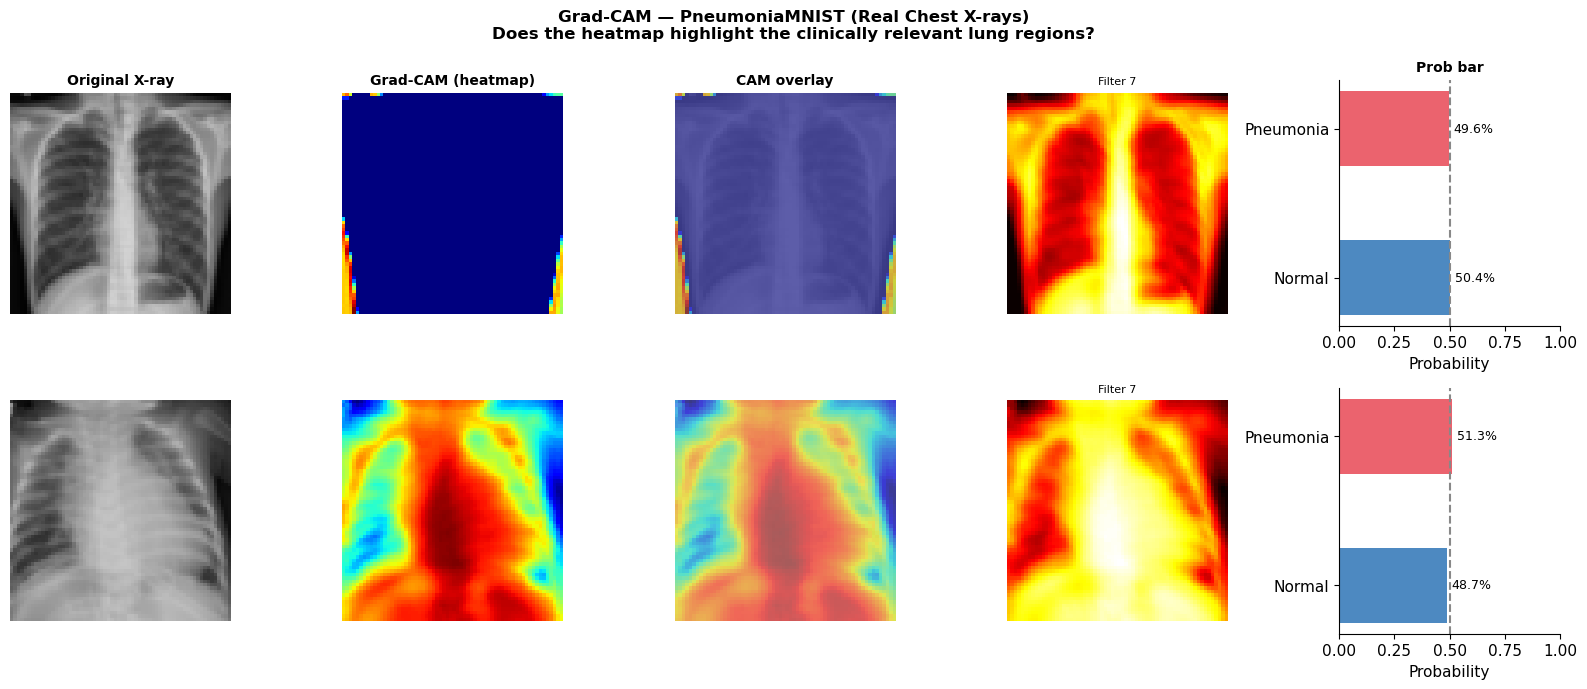

In [11]:
# ── Grad-CAM on correctly classified cases ────────────────────────────────────
preds_all = np.argmax(cnn.predict_batch(Ximg_te), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
col_titles = ['Original X-ray', 'Grad-CAM (heatmap)', 'CAM overlay',
              'Strongest filter', 'Prob bar']
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontsize=10, fontweight='bold', pad=6)

for row, cls in enumerate(range(2)):
    # Find correctly predicted examples
    correct_idx = np.where((yimg_te == cls) & (preds_all == cls))[0]
    if len(correct_idx) == 0:
        correct_idx = np.where(yimg_te == cls)[0]
    idx = correct_idx[0]
    img = Ximg_te[idx]
    cam, fmaps, probs = gradcam(cnn, img, target_class=cls)
    top_filt = np.argmax(fmaps.mean(axis=(1,2)))

    # Col 0: original
    axes[row,0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[row,0].set_ylabel(f'{CLASS_NAMES[cls]}\nPred: {CLASS_NAMES[np.argmax(probs)]}',
                           fontsize=10, fontweight='bold',
                           color=SAFE if np.argmax(probs)==cls else ACCENT)
    axes[row,0].axis('off')

    # Col 1: raw heatmap
    im = axes[row,1].imshow(cam, cmap='jet', vmin=0, vmax=1)
    axes[row,1].axis('off')

    # Col 2: overlay
    axes[row,2].imshow(img, cmap='gray', alpha=0.45, vmin=0, vmax=1)
    axes[row,2].imshow(cam, cmap='jet',  alpha=0.60, vmin=0, vmax=1)
    axes[row,2].axis('off')

    # Col 3: top filter map
    axes[row,3].imshow(fmaps[top_filt], cmap='hot')
    axes[row,3].set_title(f'Filter {top_filt+1}', fontsize=8)
    axes[row,3].axis('off')

    # Col 4: probability bar
    ax_p = axes[row,4]
    colors = [NEUTRAL, ACCENT]
    ax_p.barh(CLASS_NAMES, probs, color=colors, alpha=0.85, height=0.5)
    ax_p.axvline(0.5, color='#888', lw=1.5, ls='--')
    ax_p.set_xlim(0,1); ax_p.set_xlabel('Probability')
    for i, p in enumerate(probs):
        ax_p.text(p+0.02, i, f'{p:.1%}', va='center', fontsize=9)

plt.suptitle('Grad-CAM — PneumoniaMNIST (Real Chest X-rays)\n'
             'Does the heatmap highlight the clinically relevant lung regions?',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

Misclassified: 244 / 624 (39.1%)


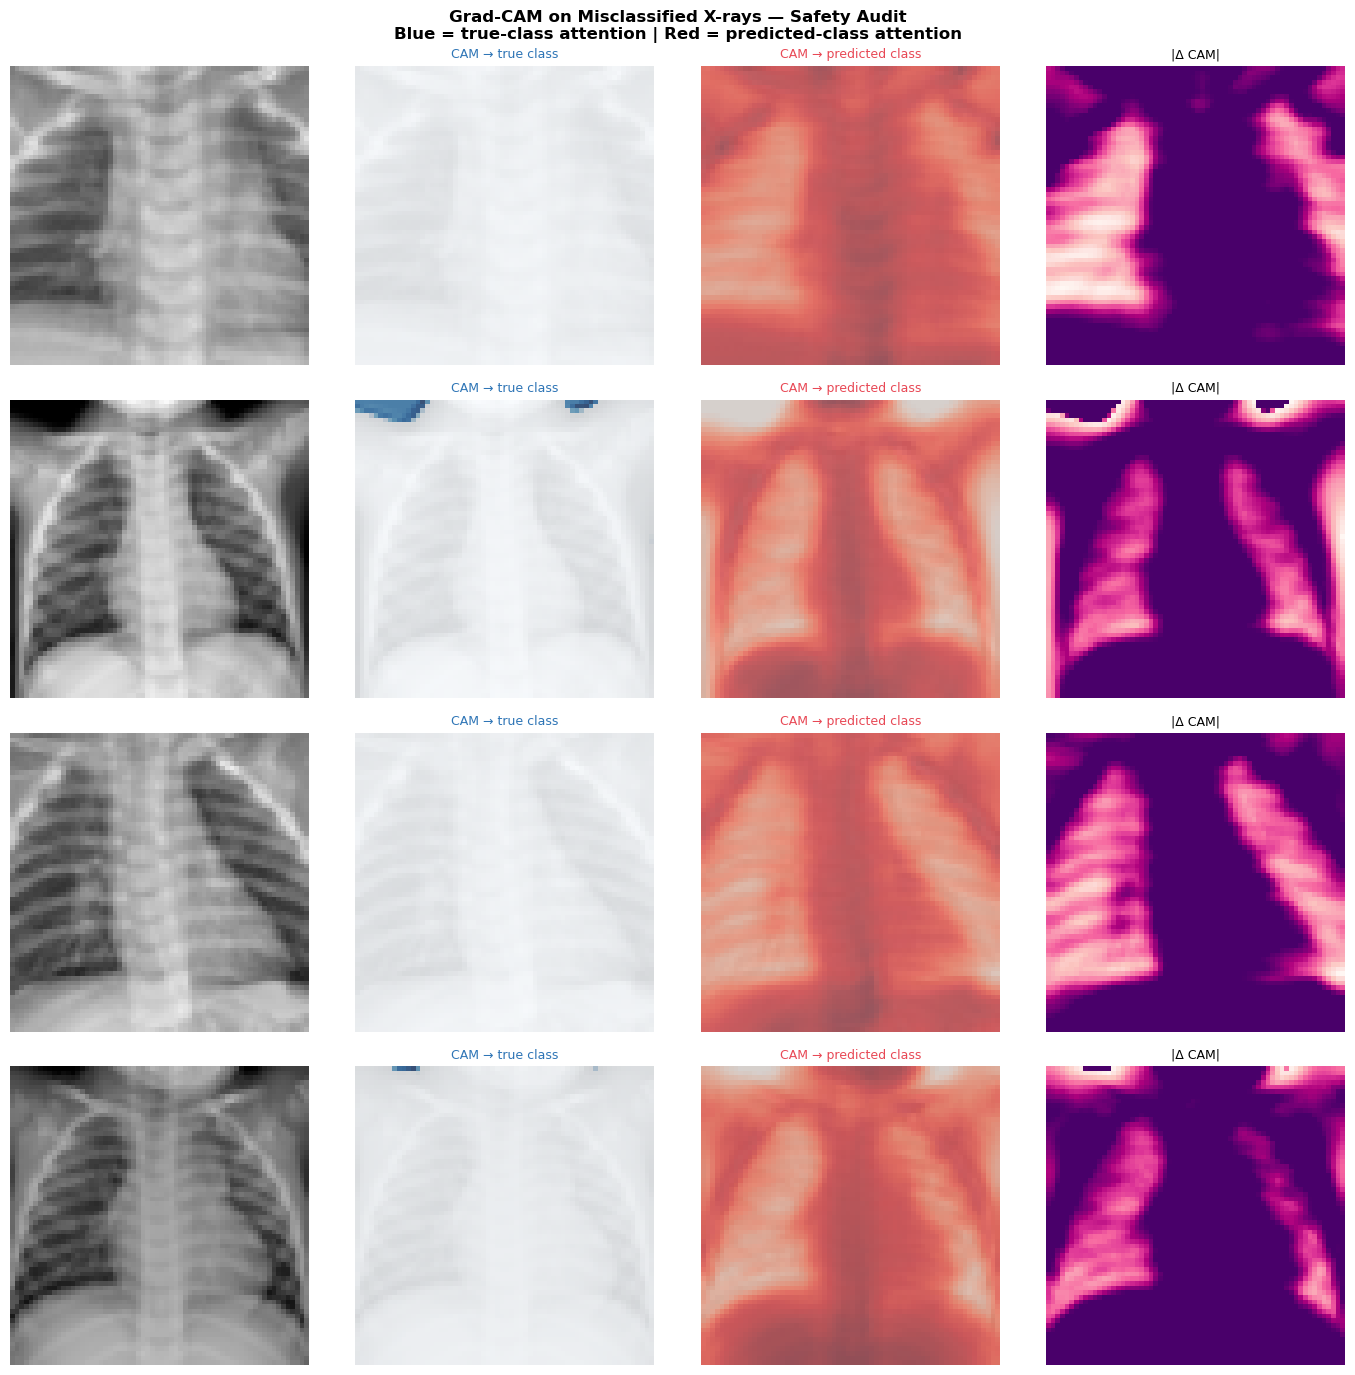

Clinical interpretation: misclassified cases reveal where the model
focused instead of the true pathology. This drives model improvement.


In [13]:
# ── Grad-CAM on misclassified cases ───────────────────────────────────────────
# Critical safety analysis: what did the model attend to when it was WRONG?
wrong_idx = np.where(preds_all != yimg_te)[0]
print(f'Misclassified: {len(wrong_idx)} / {len(Ximg_te)} ({len(wrong_idx)/len(Ximg_te):.1%})')

n_show = min(len(wrong_idx), 4)
if n_show > 0:
    fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.5*n_show))
    if n_show == 1: axes = axes[np.newaxis,:]
    for row, wi in enumerate(wrong_idx[:n_show]):
        img     = Ximg_te[wi]
        true_l  = yimg_te[wi]
        pred_l  = preds_all[wi]
        cam_t, _, pr_t = gradcam(cnn, img, target_class=int(true_l))
        cam_p, _, _    = gradcam(cnn, img, target_class=int(pred_l))

        axes[row,0].imshow(img, cmap='gray', vmin=0, vmax=1); axes[row,0].axis('off')
        axes[row,0].set_ylabel(f'True: {CLASS_NAMES[true_l]}\n'
                               f'Pred: {CLASS_NAMES[pred_l]}',
                               fontsize=9, color=ACCENT)
        axes[row,1].imshow(img, cmap='gray', alpha=0.45, vmin=0, vmax=1)
        axes[row,1].imshow(cam_t, cmap='Blues', alpha=0.65, vmin=0, vmax=1)
        axes[row,1].set_title('CAM → true class', fontsize=9, color=NEUTRAL); axes[row,1].axis('off')
        axes[row,2].imshow(img, cmap='gray', alpha=0.45, vmin=0, vmax=1)
        axes[row,2].imshow(cam_p, cmap='Reds',  alpha=0.65, vmin=0, vmax=1)
        axes[row,2].set_title('CAM → predicted class', fontsize=9, color=ACCENT); axes[row,2].axis('off')
        # Difference
        axes[row,3].imshow(np.abs(norm01(cam_p)-norm01(cam_t)), cmap='RdPu', vmin=0, vmax=0.6)
        axes[row,3].set_title('|Δ CAM|', fontsize=9); axes[row,3].axis('off')

    plt.suptitle('Grad-CAM on Misclassified X-rays — Safety Audit\n'
                 'Blue = true-class attention | Red = predicted-class attention',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('Clinical interpretation: misclassified cases reveal where the model')
    print('focused instead of the true pathology. This drives model improvement.')

---
## Section 3 — LRP: Layer-wise Relevance Propagation
🗂 **Dataset C: PneumoniaMNIST**

$$R_i^{(l)} = \sum_j \frac{z_{ij}}{z_j + \varepsilon \cdot \text{sign}(z_j)} R_j^{(l+1)}, \quad z_{ij} = x_i^{(l)} w_{ij}$$

**Conservation:** $\sum_i R_i^{\text{input}} \approx$ target class logit — verifiable correctness.

**LRP vs Grad-CAM on real X-rays:**
- Grad-CAM: coarser map from feature space, tuned to spatial regions
- LRP: propagates pixel-level relevance backwards — higher resolution
- For pneumonia, LRP should highlight the specific pixels with elevated intensity
  corresponding to actual consolidation or infiltrate patterns


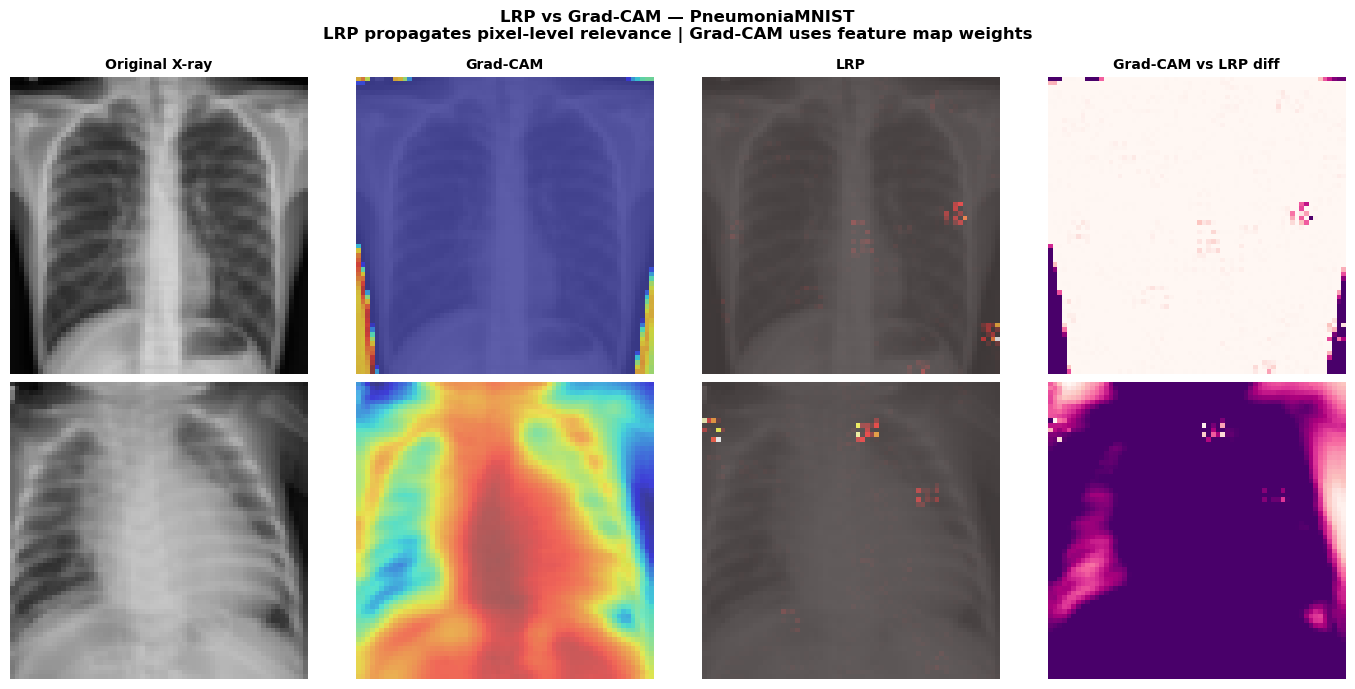

Spatial correlation Grad-CAM vs LRP (pneumonia case): r=-0.029

Clinical note: High correlation → methods agree on which lung regions matter.
Low correlation → the two methods capture different aspects of the decision.
For regulatory audit, high cross-method agreement increases confidence.


In [14]:
# ── LRP on real X-rays — one example per class ────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
col_titles = ['Original X-ray', 'Grad-CAM', 'LRP', 'Grad-CAM vs LRP diff']
for col, t in enumerate(col_titles):
    axes[0,col].set_title(t, fontsize=10, fontweight='bold', pad=6)

for row, cls in enumerate(range(2)):
    correct_idx = np.where((yimg_te==cls) & (preds_all==cls))[0]
    if len(correct_idx)==0: correct_idx=np.where(yimg_te==cls)[0]
    idx = correct_idx[0]
    img = Ximg_te[idx]
    cam, _, probs = gradcam(cnn, img, cls)
    lrp_map       = lrp(cnn, img, cls)
    cam_n  = norm01(cam)
    lrp_n  = norm01(lrp_map)

    axes[row,0].imshow(img,   cmap='gray',  vmin=0, vmax=1)
    axes[row,0].set_ylabel(f'{CLASS_NAMES[cls]} ({probs[cls]:.0%})',
                           fontsize=10, fontweight='bold'); axes[row,0].axis('off')
    axes[row,1].imshow(img,   cmap='gray',  alpha=0.45, vmin=0, vmax=1)
    axes[row,1].imshow(cam_n, cmap='jet',   alpha=0.60, vmin=0, vmax=1); axes[row,1].axis('off')
    axes[row,2].imshow(img,   cmap='gray',  alpha=0.45, vmin=0, vmax=1)
    axes[row,2].imshow(lrp_n, cmap='hot',   alpha=0.60, vmin=0, vmax=1); axes[row,2].axis('off')
    axes[row,3].imshow(np.abs(lrp_n-cam_n), cmap='RdPu', vmin=0, vmax=0.5); axes[row,3].axis('off')

plt.suptitle('LRP vs Grad-CAM — PneumoniaMNIST\n'
             'LRP propagates pixel-level relevance | Grad-CAM uses feature map weights',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Spatial correlation between methods
from scipy.stats import pearsonr
correct_pneu = np.where((yimg_te==1) & (preds_all==1))[0]
if len(correct_pneu)>0:
    img_c  = Ximg_te[correct_pneu[0]]
    r,p    = pearsonr(norm01(gradcam(cnn,img_c,1)[0]).flatten(),
                       norm01(lrp(cnn,img_c,1)).flatten())
    print(f'Spatial correlation Grad-CAM vs LRP (pneumonia case): r={r:.3f}')
    print()
print('Clinical note: High correlation → methods agree on which lung regions matter.')
print('Low correlation → the two methods capture different aspects of the decision.')
print('For regulatory audit, high cross-method agreement increases confidence.')

---
## Section 4 — Vanilla Saliency & SmoothGrad
🗂 **Dataset C: PneumoniaMNIST**

$$\text{Saliency}(i,j) = \left|\frac{\partial F_c(x)}{\partial x_{ij}}\right|$$

SmoothGrad reduces gradient noise by averaging over $N$ noisy copies:
$$\widehat{M}_c(x) = \frac{1}{N}\sum_{n=1}^N M_c(x + \varepsilon_n), \; \varepsilon_n \sim \mathcal{N}(0,\sigma^2)$$


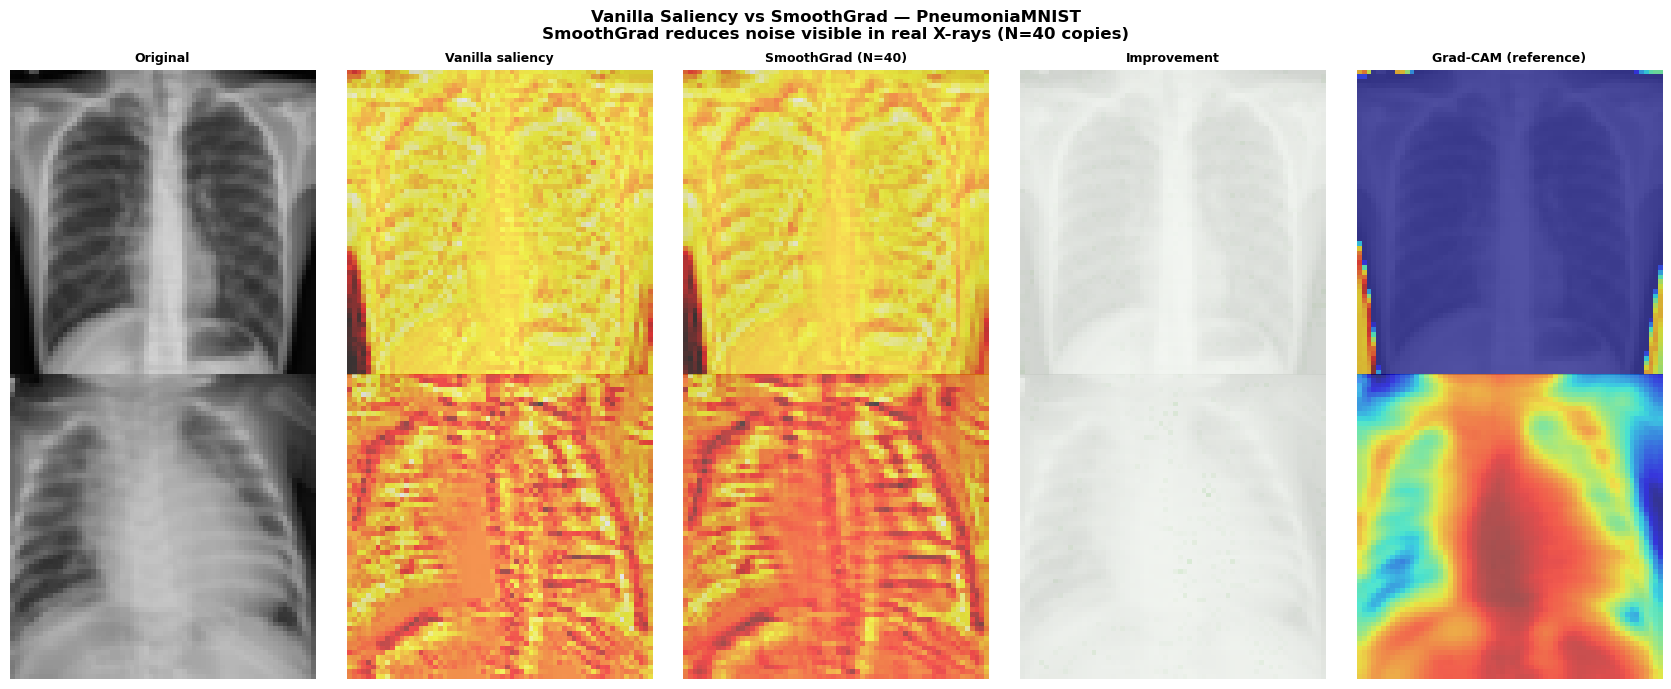

On real X-rays, SmoothGrad is especially valuable: raw gradients are noisy
due to sharp intensity transitions at rib edges. Averaging over N noisy copies
suppresses this anatomical noise and reveals the pathology-relevant signal.


In [16]:
# ── Saliency & SmoothGrad side-by-side ───────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
col_titles = ['Original', 'Vanilla saliency', 'SmoothGrad (N=40)',
              'Improvement', 'Grad-CAM (reference)']
for col, t in enumerate(col_titles): axes[0,col].set_title(t,fontsize=9,fontweight='bold',pad=6)

for row, cls in enumerate(range(2)):
    correct_idx = np.where((yimg_te==cls) & (preds_all==cls))[0]
    if len(correct_idx)==0: correct_idx=np.where(yimg_te==cls)[0]
    idx = correct_idx[0]
    img = Ximg_te[idx]

    sal  = norm01(fast_saliency(cnn, img, cls))
    sg   = norm01(smoothgrad(cnn, img, cls, n=40, noise=0.08))
    cam_n= norm01(gradcam(cnn, img, cls)[0])
    diff = np.maximum(sg - sal, 0)

    for col, (data, cmap, alpha_img) in enumerate([
        (img,  'gray', 1.0),
        (sal,  'hot',  0.0),
        (sg,   'hot',  0.0),
        (diff, 'Greens', 0.0),
        (cam_n,'jet',  0.0),
    ]):
        if alpha_img == 1.0:
            axes[row,col].imshow(data, cmap=cmap, vmin=0, vmax=1)
        else:
            axes[row,col].imshow(img,  cmap='gray', alpha=0.45, vmin=0, vmax=1)
            axes[row,col].imshow(data, cmap=cmap,   alpha=0.65, vmin=0, vmax=1)
        axes[row,col].axis('off')
    axes[row,0].set_ylabel(CLASS_NAMES[cls], fontsize=10, fontweight='bold')

plt.suptitle('Vanilla Saliency vs SmoothGrad — PneumoniaMNIST\n'
             'SmoothGrad reduces noise visible in real X-rays (N=40 copies)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('On real X-rays, SmoothGrad is especially valuable: raw gradients are noisy')
print('due to sharp intensity transitions at rib edges. Averaging over N noisy copies')
print('suppresses this anatomical noise and reveals the pathology-relevant signal.')

---
## Section 5 — Occlusion Sensitivity
🗂 **Dataset C: PneumoniaMNIST**

$$\text{Occ}(i,j) = F_c(x) - F_c(x_{\text{patch}(i,j)\leftarrow\bar{x}})$$

**Clinical advantage of occlusion:** Radiologists can intuitively understand this method —
*"if we masked that part of the lung, would the AI still flag pneumonia?"* —
without any knowledge of neural network internals.


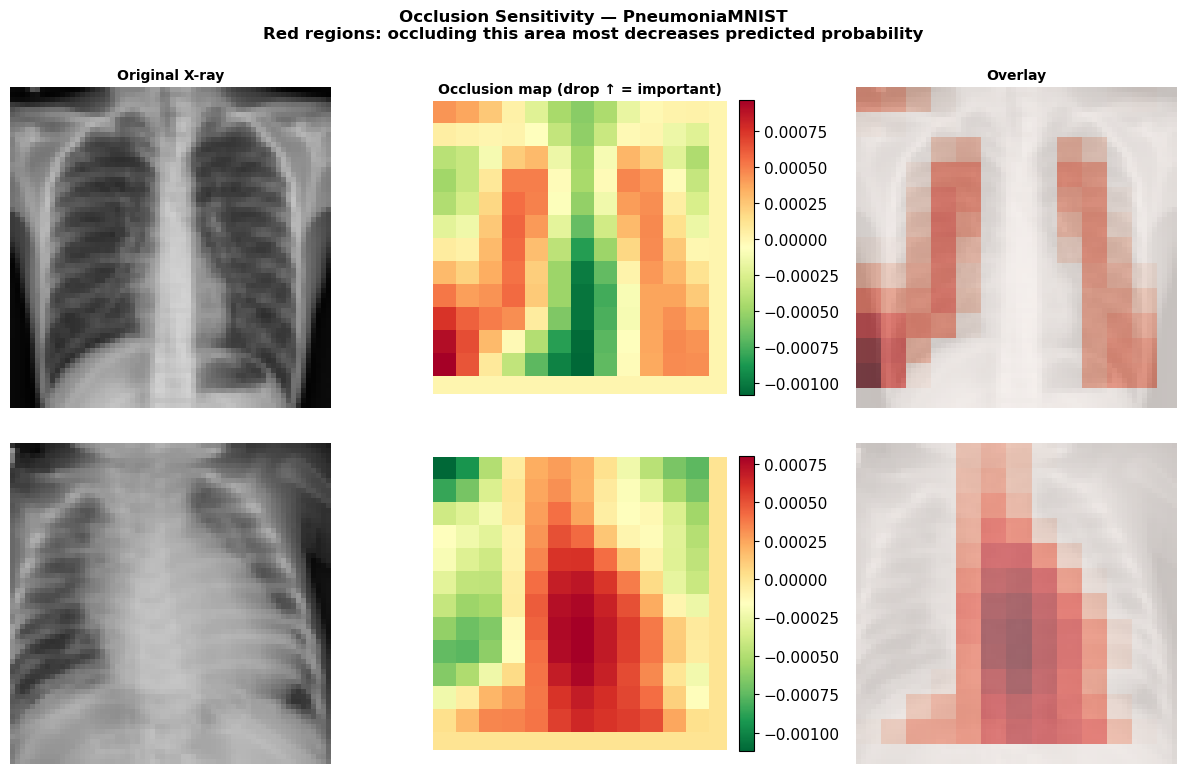

Clinical interpretation:
  Normal:    important regions should be the clear lung fields
  Pneumonia: important regions should be the opacified/bright areas

If the occlusion map highlights border artefacts or corners of the image,
the model may be exploiting imaging artefacts rather than true pathology.


In [17]:
# ── Occlusion sensitivity on real X-rays ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
col_titles = ['Original X-ray', 'Occlusion map (drop ↑ = important)', 'Overlay']
for col, t in enumerate(col_titles): axes[0,col].set_title(t,fontsize=10,fontweight='bold',pad=6)

occ_store = {}
for row, cls in enumerate(range(2)):
    correct_idx = np.where((yimg_te==cls) & (preds_all==cls))[0]
    if len(correct_idx)==0: correct_idx=np.where(yimg_te==cls)[0]
    idx = correct_idx[0]
    img = Ximg_te[idx]
    occ_map, base_p = occlusion(cnn, img, cls, patch=10, stride=5)
    occ_store[cls] = (img, occ_map, base_p)

    axes[row,0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[row,0].set_ylabel(f'{CLASS_NAMES[cls]}\nbase={base_p:.0%}',
                           fontsize=10, fontweight='bold'); axes[row,0].axis('off')
    im_occ = axes[row,1].imshow(occ_map, cmap='RdYlGn_r')
    plt.colorbar(im_occ, ax=axes[row,1], fraction=0.046, pad=0.04)
    axes[row,1].axis('off')
    axes[row,2].imshow(img, cmap='gray', alpha=0.50, vmin=0, vmax=1)
    axes[row,2].imshow(np.maximum(occ_map,0), cmap='Reds', alpha=0.55); axes[row,2].axis('off')

plt.suptitle('Occlusion Sensitivity — PneumoniaMNIST\n'
             'Red regions: occluding this area most decreases predicted probability',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Clinical interpretation:')
print('  Normal:    important regions should be the clear lung fields')
print('  Pneumonia: important regions should be the opacified/bright areas')
print()
print('If the occlusion map highlights border artefacts or corners of the image,')
print('the model may be exploiting imaging artefacts rather than true pathology.')

---
## Section 6 — Filter Activation Analysis
🗂 **Dataset C: PneumoniaMNIST**

Which CNN filters activate most strongly for Normal vs Pneumonia?
Average activation maps reveal what visual patterns the network encodes.


Computing average feature maps per class...


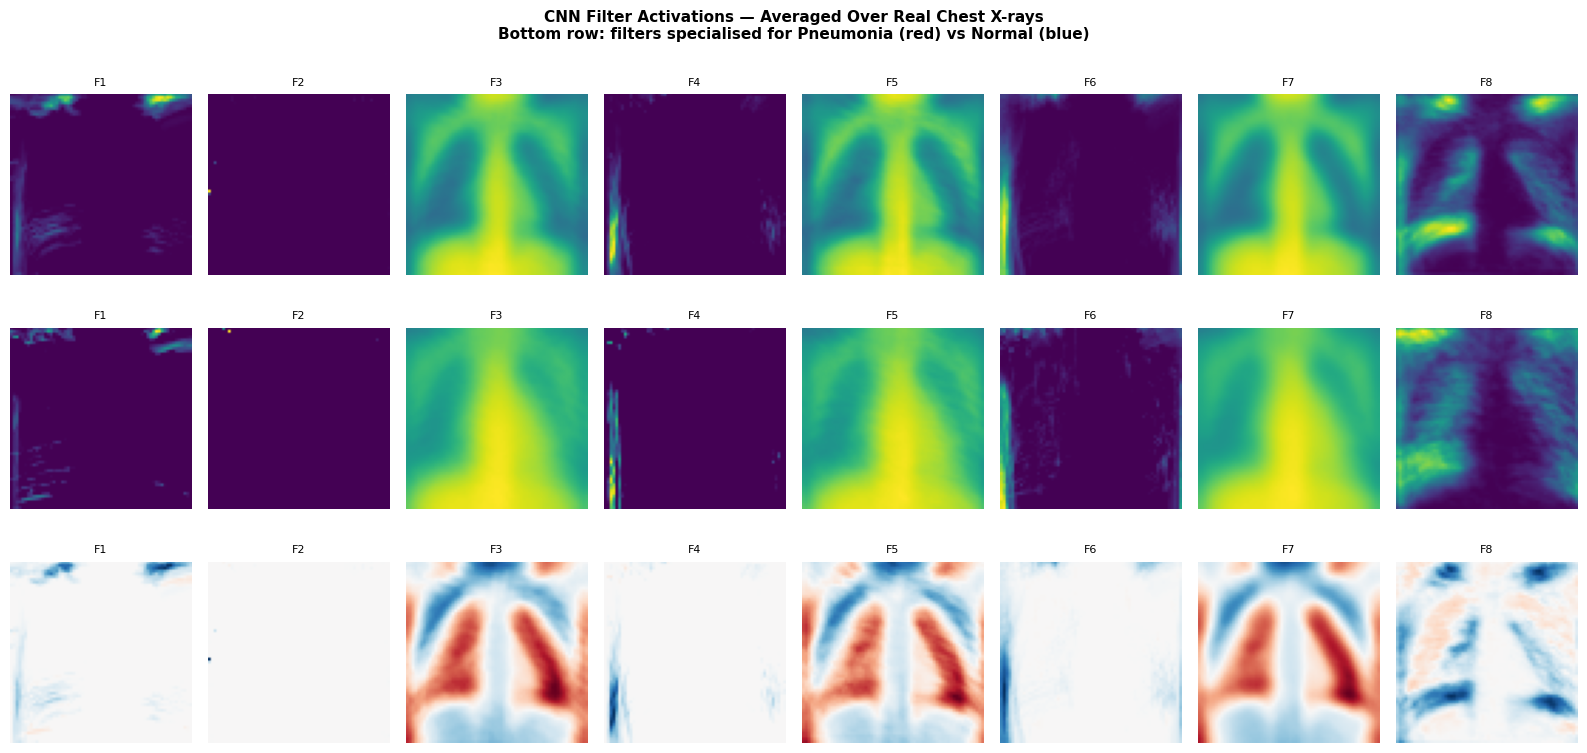

Top 5 Pneumonia-specialised filters: [np.int64(7), np.int64(13), np.int64(12), np.int64(3), np.int64(5)]
Top 5 Normal-specialised filters:    [np.int64(16), np.int64(10), np.int64(8), np.int64(15), np.int64(6)]

Filters with high Pneumonia activation tend to respond to bright,
diffuse intensity — consistent with consolidation patterns.


In [18]:
# ── Average activation maps per class ────────────────────────────────────────
print('Computing average feature maps per class...')
avg_fmaps = {}
for cls in range(2):
    cls_idx = np.where(yimg_tr == cls)[0][:80]   # 80 samples per class
    fmaps_cls = np.array([cnn.forward(Ximg_tr[i], return_fmaps=True)[1]
                           for i in cls_idx])      # (80, n_filt, 64, 64)
    avg_fmaps[cls] = fmaps_cls.mean(axis=0)        # (n_filt, 64, 64)

# Differential activation: Pneumonia minus Normal (which filters specialise?)
diff_map = avg_fmaps[1] - avg_fmaps[0]   # positive = more active for Pneumonia
filter_diff = diff_map.mean(axis=(1,2))  # (n_filt,) — scalar per filter

fig, axes = plt.subplots(3, 8, figsize=(16, 8))
row_labels = ['Normal avg activation', 'Pneumonia avg activation', 'Δ (Pneumonia − Normal)']
for row, (fmaps, row_label) in enumerate([(avg_fmaps[0], row_labels[0]),
                                           (avg_fmaps[1], row_labels[1]),
                                           (diff_map,     row_labels[2])]):
    for k in range(min(8, cnn.n_filt)):
        ax = axes[row, k]
        cmap = 'viridis' if row < 2 else 'RdBu_r'
        vmax = np.abs(fmaps[k]).max()
        ax.imshow(fmaps[k], cmap=cmap, vmin=-vmax if row==2 else 0, vmax=vmax)
        ax.set_title(f'F{k+1}', fontsize=8); ax.axis('off')
    axes[row, 0].set_ylabel(row_label, fontsize=9, fontweight='bold')

plt.suptitle('CNN Filter Activations — Averaged Over Real Chest X-rays\n'
             'Bottom row: filters specialised for Pneumonia (red) vs Normal (blue)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Which filters are most specialised for Pneumonia?
top_pneu = np.argsort(filter_diff)[::-1][:5]
top_norm = np.argsort(filter_diff)[:5]
print(f'Top 5 Pneumonia-specialised filters: {[f+1 for f in top_pneu]}')
print(f'Top 5 Normal-specialised filters:    {[f+1 for f in top_norm]}')
print()
print('Filters with high Pneumonia activation tend to respond to bright,')
print('diffuse intensity — consistent with consolidation patterns.')

---
## Section 7 — TCAV: Testing with Concept Activation Vectors
🗂 **Dataset C: PneumoniaMNIST**

TCAV tests whether the CNN has learned a human-defined **clinical concept**.
Here we define concepts from image statistics of the real X-rays:

1. **High-opacity** — images with elevated mean intensity (consolidation-like)
2. **Focal brightness** — images with high peak-to-mean ratio (nodule-like)
3. **Bilateral symmetry** — images with similar left/right intensity (normal lungs)

$$\text{TCAV}_{c,k} = \frac{|\{x \in X_k : \nabla h_k(f(x)) \cdot v_c > 0\}|}{|X_k|}$$


In [19]:
# ── TCAV on PneumoniaMNIST ────────────────────────────────────────────────────
# Extract GAP feature vectors for all training images
print('Extracting feature representations (GAP vectors)...')
gap_tr = np.array([cnn.forward(im, return_fmaps=True)[2] for im in Ximg_tr])  # (N, n_filt)
gap_te = np.array([cnn.forward(im, return_fmaps=True)[2] for im in Ximg_te])

# Define concepts from real image statistics
_mv=np.array([im.mean() for im in Ximg_tr])
_pv=np.array([im.max()-im.mean() for im in Ximg_tr])
_sv=np.array([abs(im[:,:im.shape[1]//2].mean()-im[:,im.shape[1]//2:].mean()) for im in Ximg_tr])
_ot=np.percentile(_mv,50); _ft=np.percentile(_pv,50); _st=np.percentile(_sv,50)

def high_opacity(img):      return float(img.mean()>_ot)
def focal_brightness(img):  return float((img.max()-img.mean())>_ft)
def bilateral_symmetry(img):
    l=img[:,:img.shape[1]//2].mean(); r=img[:,img.shape[1]//2:].mean()
    return float(abs(l-r)<_st)

concept_fns = {
    'High opacity':        high_opacity,
    'Focal brightness':    focal_brightness,
    'Bilateral symmetry':  bilateral_symmetry,
}

print('Concept prevalence in training set:')
for name, fn in concept_fns.items():
    labels_c = np.array([fn(im) for im in Ximg_tr])
    print(f'  {name}: {labels_c.mean():.1%} positive')

Extracting feature representations (GAP vectors)...
Concept prevalence in training set:
  High opacity: 50.0% positive
  Focal brightness: 50.0% positive
  Bilateral symmetry: 50.0% positive


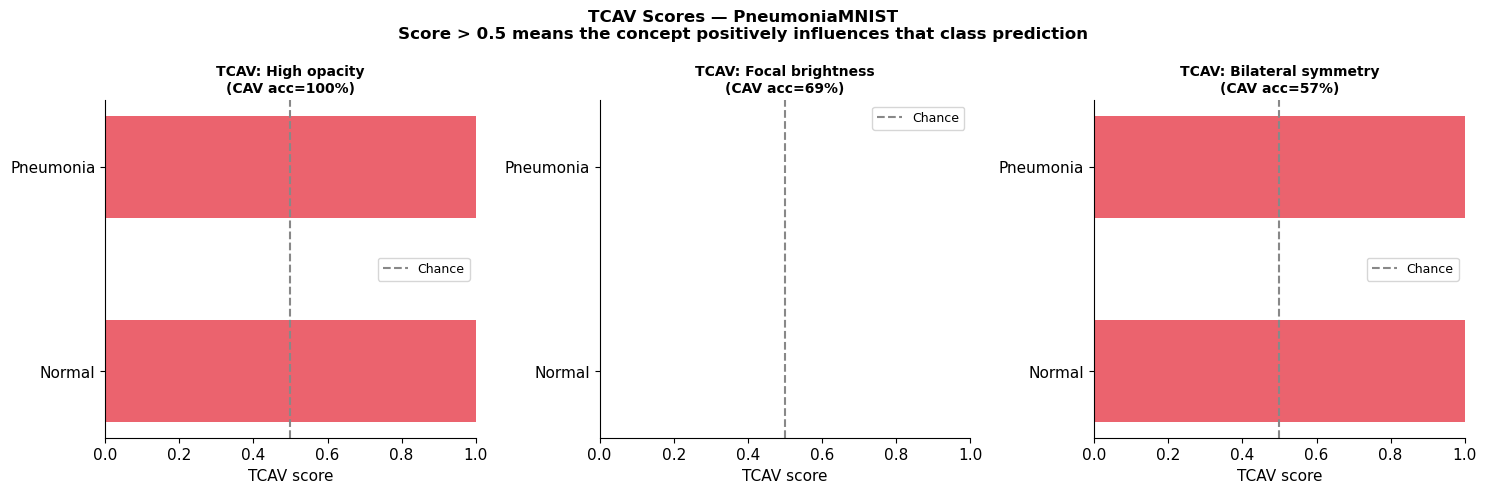

Clinical interpretation:
  High opacity          : most associated with Normal (score=1.00)
  Focal brightness      : most associated with Normal (score=0.00)
  Bilateral symmetry    : most associated with Normal (score=1.00)

Expected: "High opacity" should score highest for Pneumonia, confirming
that the CNN has learned opacity/consolidation as a discriminative concept.


In [21]:
# ── Fit CAVs and compute TCAV scores ──────────────────────────────────────────
from scipy.stats import pearsonr

tcav_results = {}
for concept_name, concept_fn in concept_fns.items():
    concept_lbl = np.array([concept_fn(im) for im in Ximg_tr])
    pos = np.where(concept_lbl == 1)[0]
    neg = np.where(concept_lbl == 0)[0]
    n_min = min(len(pos), len(neg), 150)
    if n_min < 20:
        print(f'{concept_name}: too few examples, skipping'); continue
    np.random.seed(42)
    p_idx = np.random.choice(pos, n_min, replace=False)
    n_idx = np.random.choice(neg, n_min, replace=False)
    X_cav = np.vstack([gap_tr[p_idx], gap_tr[n_idx]])
    y_cav = np.array([1]*n_min + [0]*n_min)
    cav_m = LogisticRegression(max_iter=500, random_state=42).fit(X_cav, y_cav)
    cav_v = cav_m.coef_[0]
    cav_acc = cav_m.score(X_cav, y_cav)

    scores = {}
    for cls in range(2):
        mask = yimg_te == cls
        if mask.sum() == 0: continue
        sens = gap_te[mask] @ cav_v
        scores[CLASS_NAMES[cls]] = (sens > 0).mean()
    tcav_results[concept_name] = {'scores': scores, 'cav_acc': cav_acc}

# Plot TCAV results
if not tcav_results:
    print('No TCAV results — need balanced concept examples (run with real PneumoniaMNIST data).')
else:
    fig, axes = plt.subplots(1, len(tcav_results), figsize=(5*len(tcav_results), 5))
    if len(tcav_results)==1: axes=[axes]
for ax, (concept, data) in zip(axes, tcav_results.items()):
    scores = data['scores']
    vals   = [scores.get(c, 0) for c in CLASS_NAMES]
    colors = [ACCENT if v>0.6 else NEUTRAL if v>0.5 else SAFE for v in vals]
    ax.barh(CLASS_NAMES, vals, color=colors, alpha=0.85, height=0.5)
    ax.axvline(0.5, color='#888', lw=1.5, ls='--', label='Chance')
    ax.set_title(f'TCAV: {concept}\n(CAV acc={data["cav_acc"]:.0%})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('TCAV score'); ax.legend(fontsize=9); ax.set_xlim(0,1)

plt.suptitle('TCAV Scores — PneumoniaMNIST\n'
             'Score > 0.5 means the concept positively influences that class prediction',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('Clinical interpretation:')
for concept, data in tcav_results.items():
    best = max(data['scores'], key=data['scores'].get)
    print(f'  {concept:22s}: most associated with {best} (score={data["scores"][best]:.2f})')
print()
print('Expected: "High opacity" should score highest for Pneumonia, confirming')
print('that the CNN has learned opacity/consolidation as a discriminative concept.')

---
## Section 8 — Integration: All Methods on One Clinical Case
🗂 **Dataset C: PneumoniaMNIST**

Apply all five spatial XAI methods to the same real chest X-ray and measure
their agreement. This is what a clinical AI audit would look like in practice.


In [24]:
# ── Find a clear-cut Pneumonia case ──────────────────────────────────────────
# Use the case where the model is most confident
probs_all = cnn.predict_batch(Ximg_te)
# Most confident correct Pneumonia prediction
pneu_correct = np.where((yimg_te==1) & (preds_all==1))[0]
if len(pneu_correct) == 0: pneu_correct = np.where(yimg_te==1)[0]
confidence    = probs_all[pneu_correct, 1]
case_idx      = pneu_correct[np.argmax(confidence)]
case_img      = Ximg_te[case_idx]
case_probs    = probs_all[case_idx]

print(f'Case selected: test index {case_idx}')
print(f'True label:    {CLASS_NAMES[yimg_te[case_idx]]}')
print(f'Predicted:     {CLASS_NAMES[np.argmax(case_probs)]}  '
      f'(Normal={case_probs[0]:.1%}, Pneumonia={case_probs[1]:.1%})')

# Compute all attribution maps
print('\nComputing attribution maps...')
cam_map,  _, _  = gradcam(cnn,     case_img, target_class=1)
lrp_map         = lrp(cnn,         case_img, target_class=1)
sal_map         = fast_saliency(cnn, case_img, target_class=1)
sg_map          = smoothgrad(cnn,   case_img, target_class=1, n=50, noise=0.08)
occ_map, base_p = occlusion(cnn,    case_img, target_class=1, patch=10, stride=5)

cam_n = norm01(cam_map);  lrp_n = norm01(lrp_map)
sal_n = norm01(sal_map);  sg_n  = norm01(sg_map)
occ_n = norm01(np.maximum(occ_map, 0))
consensus = norm01((cam_n + lrp_n + sal_n + sg_n + occ_n) / 5)
print('Attribution maps ready.')

Case selected: test index 442
True label:    Pneumonia
Predicted:     Pneumonia  (Normal=45.5%, Pneumonia=54.5%)

Computing attribution maps...
Attribution maps ready.


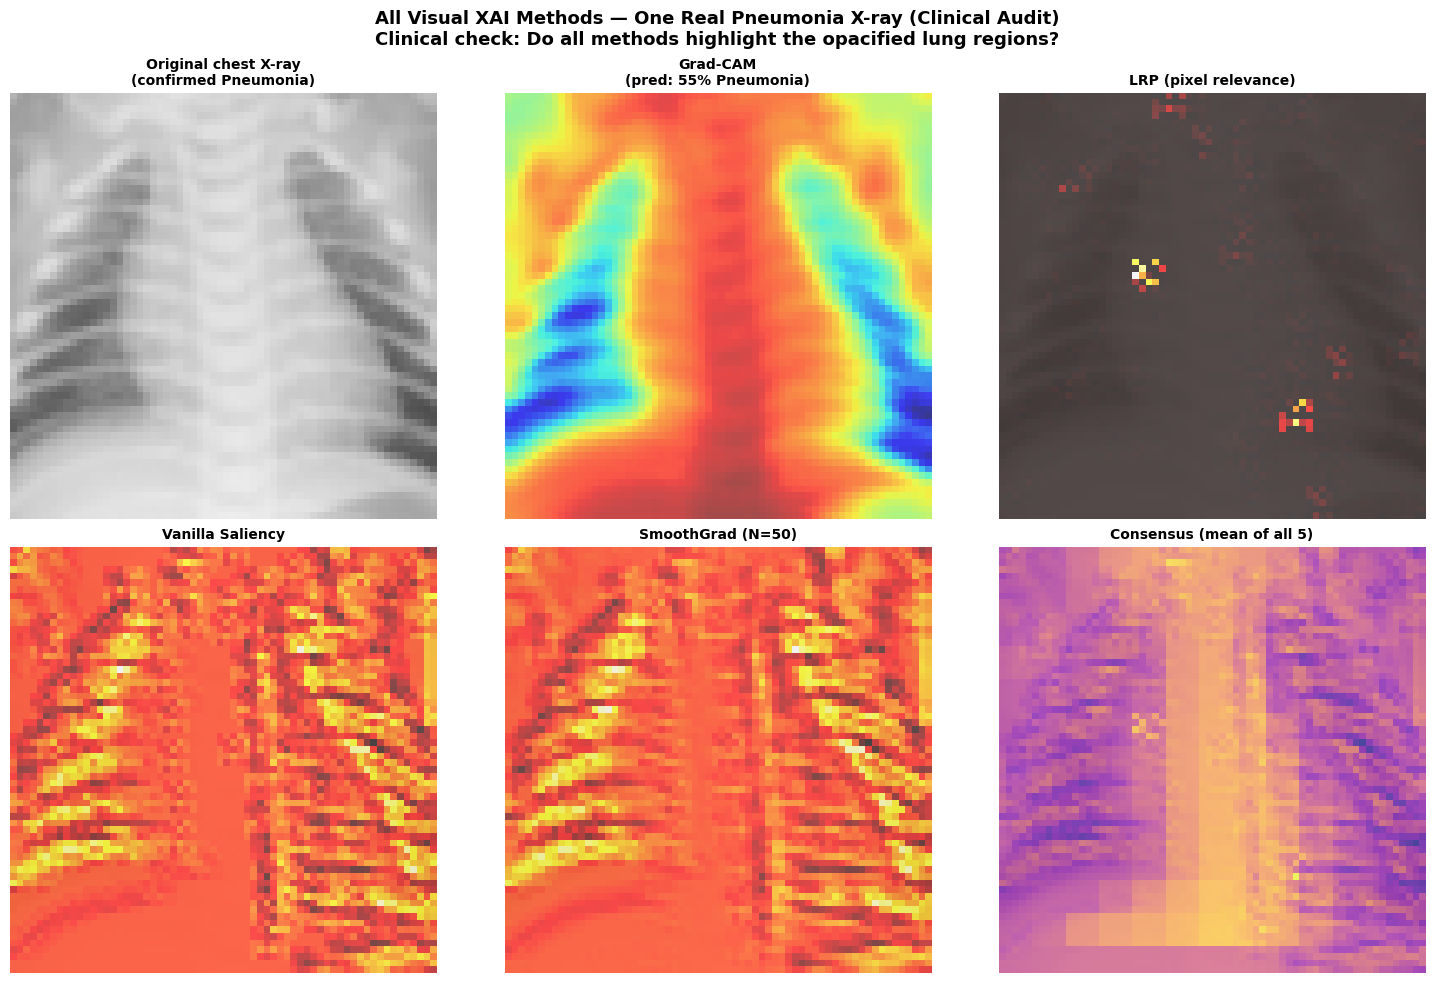

In [25]:
# ── Six-panel comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
panels = [
    (case_img,  'Original chest X-ray\n(confirmed Pneumonia)',          'gray',   1.0),
    (cam_n,     f'Grad-CAM\n(pred: {case_probs[1]:.0%} Pneumonia)',     'jet',    0.0),
    (lrp_n,     'LRP (pixel relevance)',                                  'hot',    0.0),
    (sal_n,     'Vanilla Saliency',                                       'hot',    0.0),
    (sg_n,      'SmoothGrad (N=50)',                                      'hot',    0.0),
    (consensus, 'Consensus (mean of all 5)',                              'plasma', 0.0),
]
for ax, (data, title, cmap, alpha_base) in zip(axes.flatten(), panels):
    if alpha_base == 1.0:
        ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
    else:
        ax.imshow(case_img, cmap='gray', alpha=0.40, vmin=0, vmax=1)
        ax.imshow(data,     cmap=cmap,   alpha=0.70, vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold', fontsize=10); ax.axis('off')

plt.suptitle('All Visual XAI Methods — One Real Pneumonia X-ray (Clinical Audit)\n'
             'Clinical check: Do all methods highlight the opacified lung regions?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

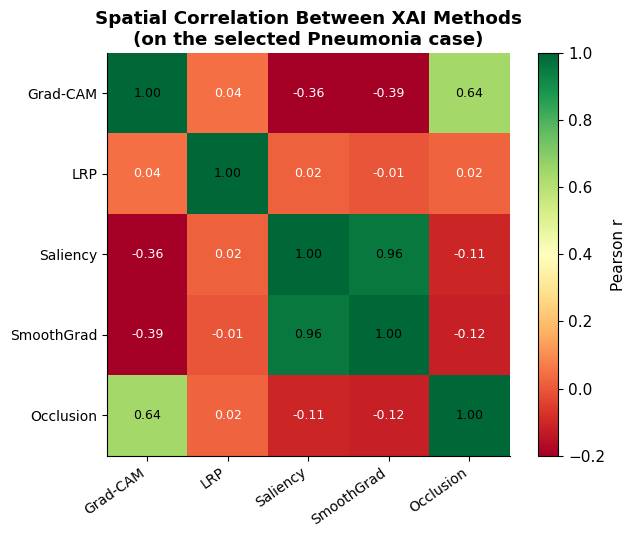

Interpretation:
  r > 0.7 — strong agreement: methods highlight the same lung regions
  r < 0.3 — weak agreement:  methods capture different aspects

For clinical deployment, regulators (EU AI Act, IMDRF SaMD) expect
cross-method consistency as evidence of explanation reliability.

Average pairwise correlation: 0.069


In [27]:
# ── Quantitative cross-method agreement ──────────────────────────────────────
from scipy.stats import pearsonr, spearmanr

methods = {'Grad-CAM':cam_n, 'LRP':lrp_n, 'Saliency':sal_n,
           'SmoothGrad':sg_n, 'Occlusion':occ_n}
names  = list(methods.keys())
maps   = list(methods.values())
n_m    = len(names)

# Pearson correlation matrix
corr_matrix = np.zeros((n_m, n_m))
for i in range(n_m):
    for j in range(n_m):
        r, _ = pearsonr(maps[i].flatten(), maps[j].flatten())
        corr_matrix[i,j] = r

fig, ax = plt.subplots(figsize=(7,5.5))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(n_m)); ax.set_xticklabels(names, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(n_m)); ax.set_yticklabels(names, fontsize=10)
for i in range(n_m):
    for j in range(n_m):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if corr_matrix[i,j]<0.4 else 'black')
ax.set_title('Spatial Correlation Between XAI Methods\n'
             '(on the selected Pneumonia case)', fontweight='bold')
plt.tight_layout(); plt.show()

print('Interpretation:')
print('  r > 0.7 — strong agreement: methods highlight the same lung regions')
print('  r < 0.3 — weak agreement:  methods capture different aspects')
print()
print('For clinical deployment, regulators (EU AI Act, IMDRF SaMD) expect')
print('cross-method consistency as evidence of explanation reliability.')
print()
avg_off_diag = corr_matrix[np.triu_indices(n_m, k=1)].mean()
print(f'Average pairwise correlation: {avg_off_diag:.3f}')

---
## Section 9 — Normal vs Pneumonia: Comparative XAI Audit
🗂 **Dataset C: PneumoniaMNIST**

Run the full XAI pipeline on both a Normal and a Pneumonia case side-by-side.
This is the standard clinical validation workflow: compare what the model
attends to in each class and verify it matches radiological knowledge.


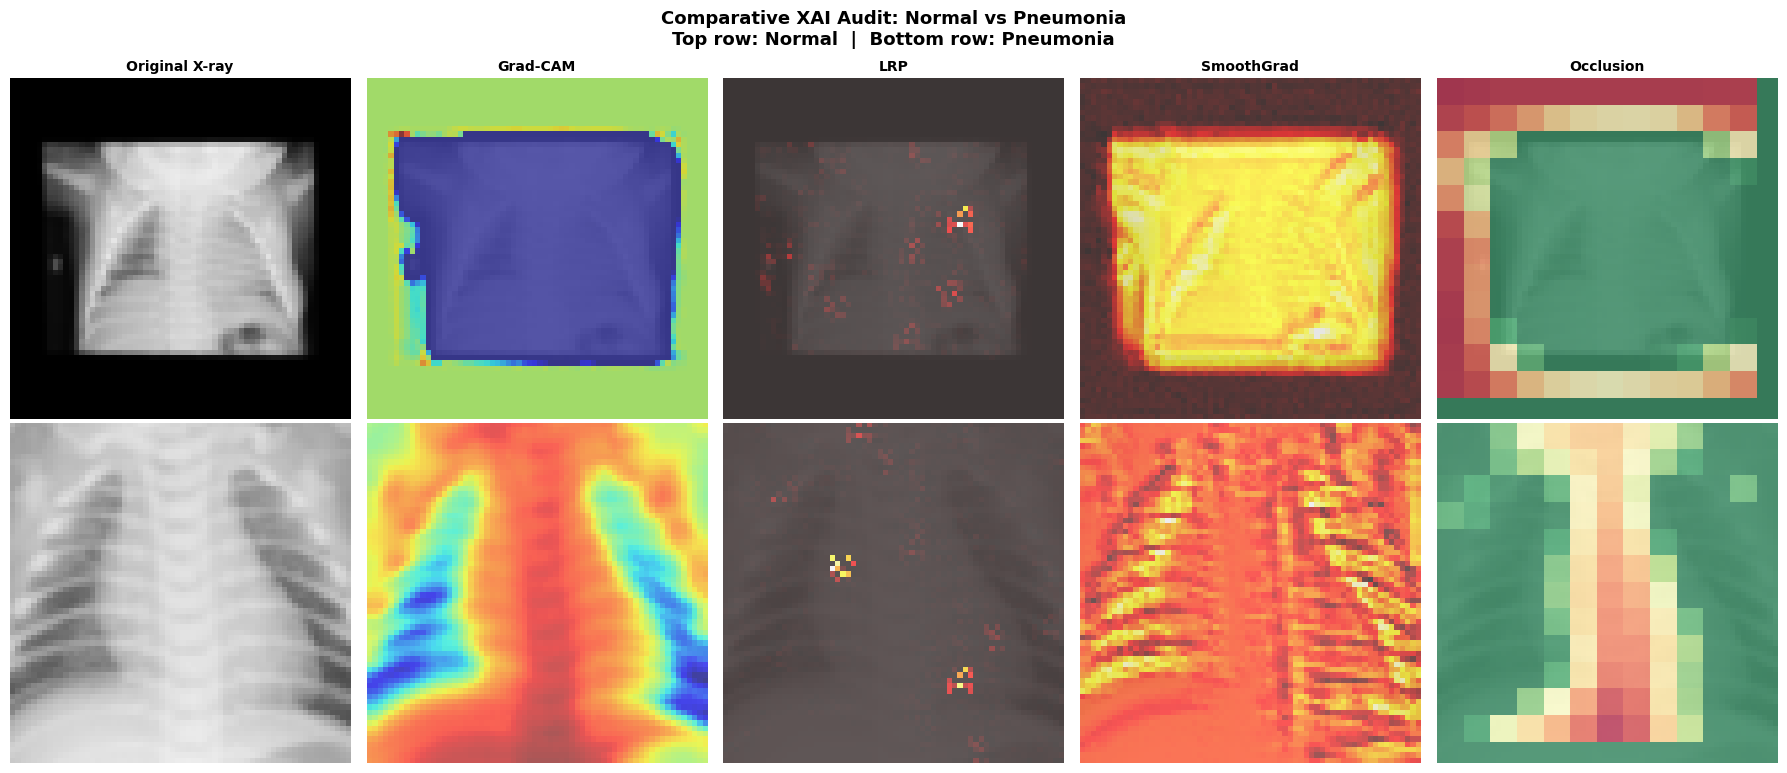

Clinical validation questions:
  1. Normal:    do XAI maps show diffuse, low-intensity attention (clear fields)?
  2. Pneumonia: do XAI maps concentrate on the brighter, opacified regions?
  3. Are the attention patterns anatomically plausible (central lung, not borders)?
  4. Do all four methods agree, or does one method give anomalous results?


In [29]:
# ── Side-by-side audit: Normal vs Pneumonia ──────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
methods_show = ['Grad-CAM', 'LRP', 'SmoothGrad', 'Occlusion']
axes[0,0].set_title('Original X-ray', fontsize=10, fontweight='bold', pad=6)
for col, name in enumerate(methods_show):
    axes[0, col+1].set_title(name, fontsize=10, fontweight='bold', pad=6)

cmaps_row = ['jet', 'hot', 'hot', 'RdYlGn_r']
for row, cls in enumerate(range(2)):
    correct_idx = np.where((yimg_te==cls) & (preds_all==cls))[0]
    if len(correct_idx)==0: correct_idx=np.where(yimg_te==cls)[0]
    # Pick the most confident correct case
    conf = probs_all[correct_idx, cls]
    idx  = correct_idx[np.argmax(conf)]
    img  = Ximg_te[idx]
    p    = probs_all[idx, cls]

    c_n = norm01(gradcam(cnn, img, cls)[0])
    l_n = norm01(lrp(cnn, img, cls))
    s_n = norm01(smoothgrad(cnn, img, cls, n=40))
    o_n = norm01(np.maximum(occlusion(cnn, img, cls)[0], 0))
    maps_row = [c_n, l_n, s_n, o_n]

    axes[row,0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[row,0].set_ylabel(f'{CLASS_NAMES[cls]}\n(confidence: {p:.0%})',
                           fontsize=10, fontweight='bold'); axes[row,0].axis('off')
    for col, (m, cmap) in enumerate(zip(maps_row, cmaps_row)):
        axes[row, col+1].imshow(img, cmap='gray', alpha=0.40, vmin=0, vmax=1)
        axes[row, col+1].imshow(m,   cmap=cmap,   alpha=0.65, vmin=0, vmax=1)
        axes[row, col+1].axis('off')

plt.suptitle('Comparative XAI Audit: Normal vs Pneumonia\n'
             'Top row: Normal  |  Bottom row: Pneumonia',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Clinical validation questions:')
print('  1. Normal:    do XAI maps show diffuse, low-intensity attention (clear fields)?')
print('  2. Pneumonia: do XAI maps concentrate on the brighter, opacified regions?')
print('  3. Are the attention patterns anatomically plausible (central lung, not borders)?')
print('  4. Do all four methods agree, or does one method give anomalous results?')

---
## Summary: Visual XAI on Real Medical Images

| Method | Resolution | Gradient? | Model-agnostic | Clinical use |
|---|---|---|---|---|
| **Grad-CAM** | Medium | Yes | No (needs GAP) | Localise what the model "saw" |
| **LRP** | High (pixel) | Yes | No (needs arch.) | Detailed pixel audit, conservation check |
| **Vanilla Saliency** | High | Yes | Partial | Fast, noisy; baseline |
| **SmoothGrad** | High | Yes | Partial | Noise-reduced; preferred over vanilla |
| **Occlusion** | Patch-level | No | Yes (any model) | Clinician-intuitive; regulatory-friendly |
| **TCAV** | Feature space | Yes | Partial | Concept-level validation |

### Key differences: real images vs synthetic images
On **synthetic** images, all methods will always look reasonable because the
patterns are artificially clean. On **real** PneumoniaMNIST X-rays:
- Images have realistic artefacts: uneven exposure, rib shadows, cardiac silhouette
- The CNN may learn spurious correlations (e.g., label text, image borders in the original dataset)
- XAI methods reveal these shortcuts — which is exactly their clinical safety value

### Course-level synthesis
After working through NB1–NB5, you have applied XAI to:
- **Tabular risk factors** (Diabetes, Heart Disease) — interpretable models, SHAP, LIME, counterfactuals
- **Real medical images** (Chest X-rays) — Grad-CAM, LRP, Saliency, Occlusion, TCAV

The unifying principle across all settings: **XAI is not a technical add-on — it is the
mechanism that makes AI clinically safe, regulatorily compliant, and ethically accountable.**

### Final discussion questions
1. A Grad-CAM heatmap on a Normal X-ray concentrates on the **top-left corner** of the image. What does this tell you? What should the clinical team do?
2. TCAV shows "High opacity" has a TCAV score of 0.82 for Pneumonia but only 0.54 for Normal. Is this expected? Does this validate the model?
3. The LRP and Grad-CAM maps for the same case have Pearson r = 0.15. Should you trust either explanation? Which would you report to a regulator?
4. You are deploying this model in a hospital. The EU AI Act classifies it as High-Risk. Which single XAI method would you include in the regulatory submission, and why?

---
### Dataset Citation
Kermany, D. S., Goldbaum, M., Cai, W., et al. (2018). Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning. *Cell*, 172(5), 1122–1131. https://doi.org/10.1016/j.cell.2018.02.010

Yang, J., Shi, R., Wei, D., et al. (2023). MedMNIST v2 — A large-scale lightweight benchmark for 2D and 3D biomedical image classification. *Scientific Data*, 10, 41. https://doi.org/10.1038/s41597-022-01721-8
